In [22]:
from P42016_DESAT import desat_extract_TOLL
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os

In [23]:
def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [24]:
tss_file = 'Tek20251212T134111.tss'
folder = r'Y:\TESTDATA\DP\2025\12\12'
path = find_file(tss_file, folder)
time1, time2, time3, blanking_react, desat_is, desat_vcl, desat_vd = desat_extract_TOLL(path, tss_file)
print(time1, time2, time3, blanking_react, desat_is, desat_vcl, desat_vd)

-8170.233421926187 711.6529583595297 1150.856686904608 439.2037285450782 195.46874999999997 6.686770833333334 9.104166666666666


In [ ]:
tss = TSSFile(path, tss_file, source='Local')
channel_labels = tss.channel_labels
num = len(channel_labels.keys())
print(channel_labels)
time = tss.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9
vcl = tss.waveforms['ch6'].values_for_frame(0)
vd = tss.waveforms['ch3'].values_for_frame(0)
isv = tss.waveforms['ch4'].values_for_frame(0)
vg = tss.waveforms['ch1'].values_for_frame(0)

{'ch1': 'Vg', 'ch3': 'Vd', 'ch4': 'Is', 'ch6': 'Vcl', 'ch7': 'Vghs', 'ch8': 'Ig'}


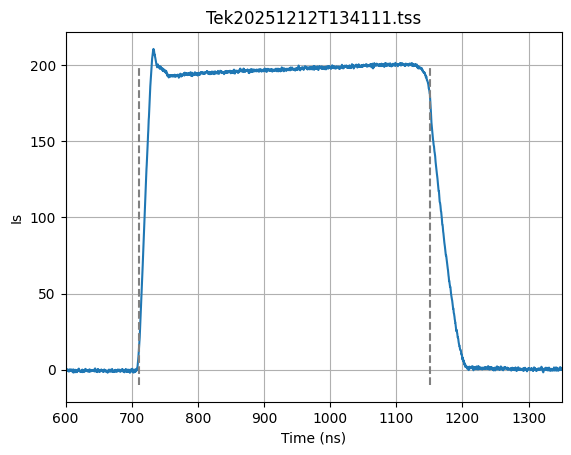

In [29]:
plt.plot(time, isv)
plt.vlines(time1, -10, 200, color='grey', linestyle='--')
plt.vlines(time2, -10, 200, color='grey', linestyle='--')
plt.vlines(time3, -10, 200, color='grey', linestyle='--')
plt.ylabel('Is')
plt.xlabel('Time (ns)')
plt.xlim([600, 1350])
plt.title(f'{tss_file}')
plt.grid()
plt.show()

0.9599999999991269


C:\Users\FeiyuanYang\AppData\Local\Temp\ipykernel_54196\2281027570.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


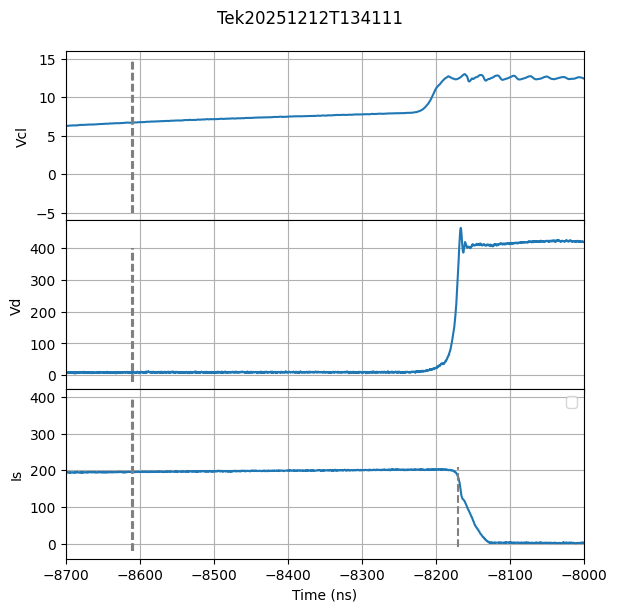

In [38]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(6, 6))
fig.suptitle(tss_file[:-4])
fig.tight_layout()
fig.subplots_adjust(hspace=0)

interval = time[1] - time[0]
print(interval * 6)
axs[0].plot(time, vcl)
axs[0].set_ylabel('Vcl')
axs[0].vlines(time1 - blanking_react - interval*3, -5, 15, color='grey', linestyle='--')
axs[0].vlines(time1 - blanking_react + interval*3, -5, 15, color='grey', linestyle='--')
axs[0].grid(True)
axs[1].plot(time, vd)
axs[1].set_ylabel('Vd')
axs[1].vlines(time1 - blanking_react - interval*3, -20, 400, color='grey', linestyle='--')
axs[1].vlines(time1 - blanking_react + interval*3, -20, 400, color='grey', linestyle='--')
axs[1].grid(True)
axs[2].plot(time, isv)
axs[2].set_ylabel('Is')
axs[2].vlines(time1 - blanking_react - interval*3, -20, 400, color='grey', linestyle='--')
axs[2].vlines(time1 - blanking_react + interval*3, -20, 400, color='grey', linestyle='--')
axs[2].vlines(time1, -10, 210, color='grey', linestyle='--')
axs[2].grid(True)

plt.legend()
plt.xlabel('Time (ns)')
plt.xlim([-8700, -8000])
#plt.legend(loc='best')
plt.show()